## Notes
1. This dataset contains flight_ticket details of 48 days ranging from `2022-02-11` to `2022-03-31` 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("economy_cleaned.csv", parse_dates=["date"], dtype={'via_city': str})

In [3]:
df.head(10)

,date,airline,ch_code,flight_number,from,to,via_city,route,stop_count,arr_hour,arr_period,dep_hour,dep_period,duration_mins,price
0,2022-02-11,SpiceJet,SG,8709,Delhi,Mumbai,NaN,Delhi-Mumbai,0,21,Night,18,Evening,130,5953
1,2022-02-11,SpiceJet,SG,8157,Delhi,Mumbai,NaN,Delhi-Mumbai,0,8,Morning,6,Morning,140,5953
2,2022-02-11,AirAsia,I5,764,Delhi,Mumbai,NaN,Delhi-Mumbai,0,6,Morning,4,Late_Night,130,5956
3,2022-02-11,Vistara,UK,995,Delhi,Mumbai,NaN,Delhi-Mumbai,0,12,Afternoon,10,Morning,135,5955
4,2022-02-11,Vistara,UK,963,Delhi,Mumbai,NaN,Delhi-Mumbai,0,11,Morning,8,Morning,140,5955
5,2022-02-11,Vistara,UK,945,Delhi,Mumbai,NaN,Delhi-Mumbai,0,14,Afternoon,11,Morning,140,5955
6,2022-02-11,Vistara,UK,927,Delhi,Mumbai,NaN,Delhi-Mumbai,0,11,Morning,9,Morning,125,6060
7,2022-02-11,Vistara,UK,951,Delhi,Mumbai,NaN,Delhi-Mumbai,0,16,Afternoon,14,Afternoon,130,6060
8,2022-02-11,GO FIRST,G8,334,Delhi,Mumbai,NaN,Delhi-Mumbai,0,10,Morning,8,Morning,130,5954
9,2022-02-11,GO FIRST,G8,336,Delhi,Mumbai,NaN,Delhi-Mumbai,0,16,Afternoon,14,Afternoon,135,5954


In [4]:
print("First_date:", df['date'].min())
print("\nLast_date:", df['date'].max())
print("\nduration:", (df['date'].max() - df['date'].min()))

First_date: 2022-02-11 00:00:00

Last_date: 2022-03-31 00:00:00

duration: 48 days 00:00:00


## **Univariate Analysis**

## Price
**Overall median price hai `₹5,772`. `Vistara` ka median (₹6,461) is se zyada hai, baaki saari airlines is se kam hain.**

**Skewness `1.70` hai — kaafi right-skewed hai (business class mein ye bohot kam thi). `6.65%` prices IQR-based outliers hain (upper bound ₹13,105).**

count    206772.000000
mean       6571.172383
std        3743.438765
min        1105.000000
25%        4173.000000
50%        5772.000000
75%        7746.000000
max       42349.000000
Name: price, dtype: float64
airline
Air India    6082.0
AirAsia      3276.0
GO FIRST     5336.0
Indigo       4453.0
SpiceJet     5654.0
StarAir      4337.0
Trujet       3196.0
Vistara      6461.0
Name: price, dtype: float64


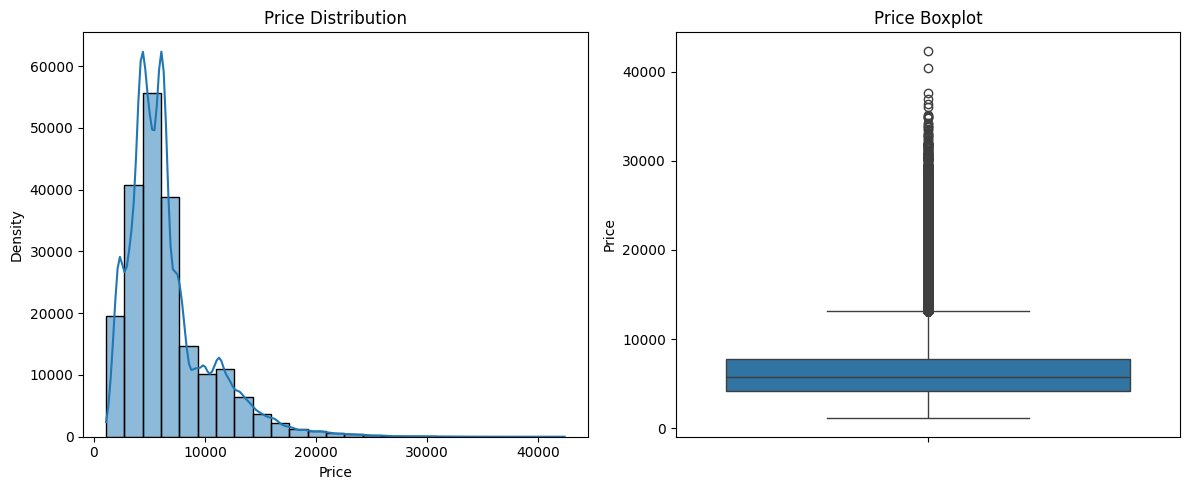

outliers_pct: 6.64983653492736
skewness: 1.703248756075069


In [5]:
print(df['price'].describe())
print(df.groupby('airline')['price'].median())

plt.figure(figsize= (12, 5))
plt.subplot(121)
sns.histplot(df['price'], bins= 25, edgecolor= 'black', kde= True)
plt.xlabel('Price')
plt.ylabel('Density')
plt.title('Price Distribution')

plt.subplot(122)
sns.boxplot(df['price'])
plt.ylabel('Price')
plt.title('Price Boxplot')

plt.tight_layout()
plt.show()

# outliers 
df['price'].skew()
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1
upper_bound = IQR * 1.5 + Q3

outliers = df[df['price'] > upper_bound]
print('outliers_pct:', len(outliers)*100/len(df))

print('skewness:',df['price'].skew())

## Airline
**8 airlines hain economy mein (business mein sirf 2 the) — `Vistara`(32.53%) sabse zyada listings, phir `Air India`(23.21%), `Indigo`(20.85%), `GO FIRST`(11.21%), `AirAsia`(7.79%), `SpiceJet`(4.36%).**

**`StarAir` ke paas sirf 61 listing hai aur `Trujet` ke paas 41 — inka sample size bohot chota hai isliye inke stats pe zyada trust mat karo.**

airline
Vistara      32.533418
Air India    23.211073
Indigo       20.853887
GO FIRST     11.208964
AirAsia       7.785387
SpiceJet      4.357940
StarAir       0.029501
Trujet        0.019829
Name: count, dtype: float64


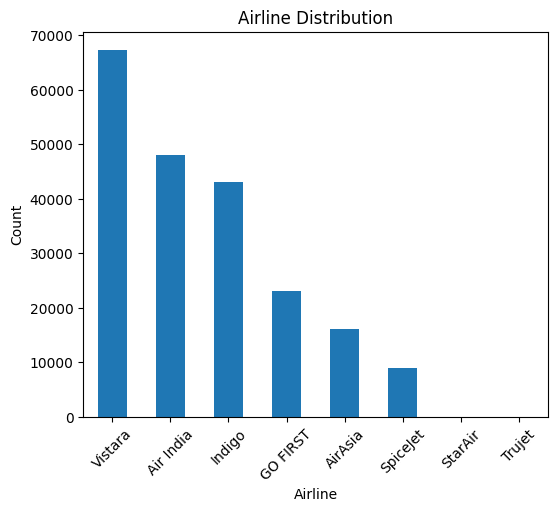

airline
StarAir    61
Trujet     41
Name: count, dtype: int64


In [6]:
print(df['airline'].value_counts()*100/len(df))

fig = plt.figure(figsize= (6,5))
df['airline'].value_counts().plot(kind= 'bar')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.title('Airline Distribution')
plt.xticks(rotation= 45)
plt.show()

print(df[df['airline'].isin(['StarAir','Trujet'])]['airline'].value_counts())

## `Route`
**Dataset routes mein well-distributed hai. `Delhi-Bangalore` route sabse frequent hai (`4.91%`), aur `Chennai-Bangalore` sabse kam frequent (`1.99%`).**

route
Delhi-Bangalore        4.905887
Delhi-Mumbai           4.827540
Bangalore-Delhi        4.816416
Mumbai-Delhi           4.740003
Mumbai-Kolkata         4.243321
Bangalore-Mumbai       4.228812
Mumbai-Bangalore       4.210435
Delhi-Kolkata          4.185286
Kolkata-Mumbai         3.918809
Kolkata-Delhi          3.780009
Delhi-Chennai          3.707465
Chennai-Delhi          3.414389
Hyderabad-Mumbai       3.385371
Mumbai-Hyderabad       3.383920
Kolkata-Bangalore      3.334107
Bangalore-Kolkata      3.331205
Mumbai-Chennai         3.272687
Delhi-Hyderabad        3.182733
Chennai-Mumbai         3.040547
Hyderabad-Delhi        2.910452
Bangalore-Hyderabad    2.880951
Hyderabad-Kolkata      2.713133
Kolkata-Hyderabad      2.686534
Hyderabad-Bangalore    2.518716
Chennai-Kolkata        2.346062
Kolkata-Chennai        2.179212
Hyderabad-Chennai      2.008976
Bangalore-Chennai      1.991082
Chennai-Hyderabad      1.939818
Chennai-Bangalore      1.916120
Name: count, dtype: float64


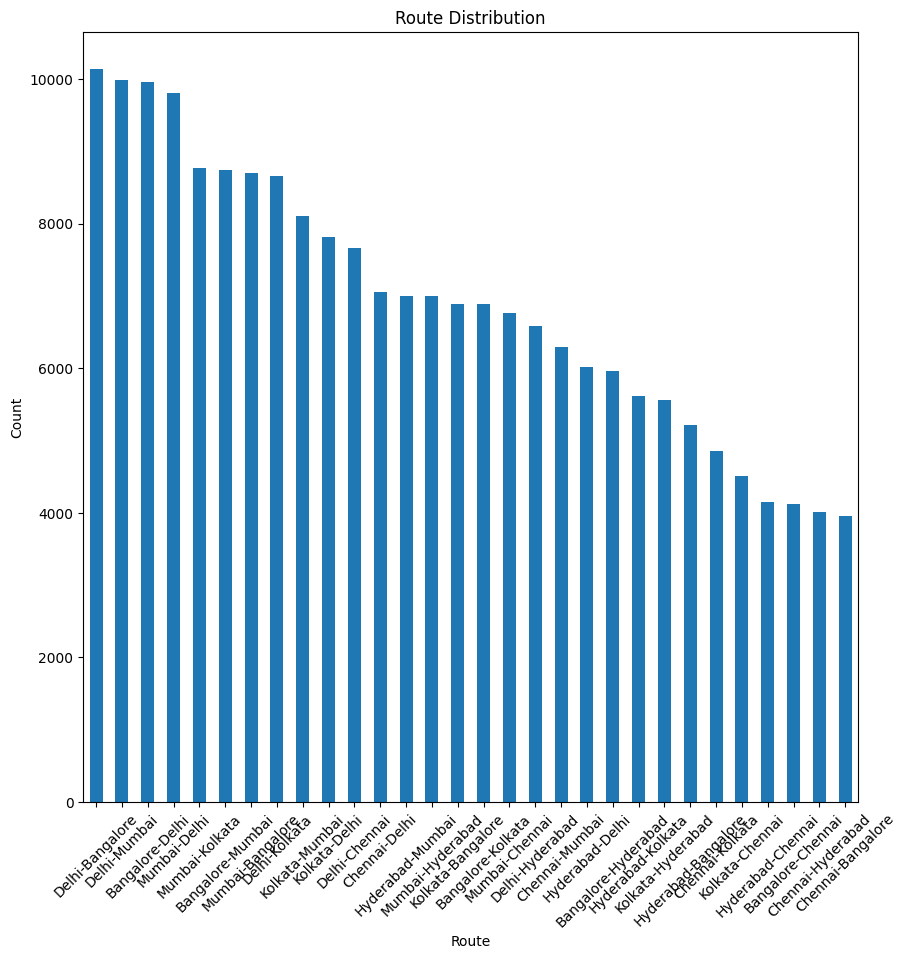

In [7]:
print(df['route'].value_counts()*100/len(df))

plt.figure(figsize=(10,10))
df['route'].value_counts().plot(kind='bar')
plt.xlabel('Route')
plt.ylabel('Count')
plt.title('Route Distribution')
plt.xticks(rotation= 45)
plt.show()

## `Stop Count`
**`1-stoppage` `80.58%` hai (business mein 90.17% tha — economy mein non-stop options zyada available hain).**

**`0-stoppage` `13.51%` hai (business mein sirf 8.67% tha), aur `2-stoppage` `5.90%` hai (business mein 1.16% tha).**

**Almost saari major airlines ka median stop_count `1` hai (StarAir/Trujet chote sample size ki wajah se count nahi kiye).**

stop_count
1    80.583928
0    13.513435
2     5.902637
Name: count, dtype: float64


airline
Air India    1.0
AirAsia      1.0
GO FIRST     1.0
Indigo       1.0
SpiceJet     1.0
StarAir      0.0
Trujet       1.0
Vistara      1.0
Name: stop_count, dtype: float64


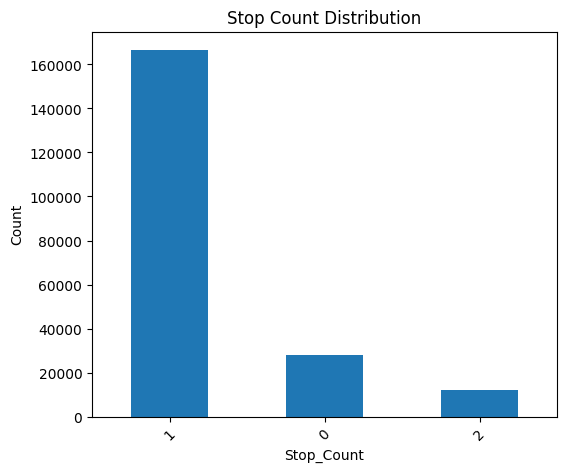

In [8]:
print(df['stop_count'].value_counts()*100/len(df))
print(df.groupby('airline')['stop_count'].median())

plt.figure(figsize=(6,5))
df['stop_count'].value_counts().plot(kind='bar')
plt.xlabel('Stop_Count')
plt.ylabel('Count')
plt.title('Stop Count Distribution')
plt.xticks(rotation= 45)
plt.show()

## Arrival hour
**Overall median `17` hours hai — business jaisa hi.**

**Highest median `StarAir` (19 hrs, chota sample) phir `Vistara` (18 hrs), lowest `Trujet` (11 hrs, chota sample) phir `AirAsia` (12 hrs).**

count    206772.000000
mean         15.036194
std           6.230907
min           0.000000
25%          10.000000
50%          17.000000
75%          20.000000
max          23.000000
Name: arr_hour, dtype: float64
             count       mean       std   min   25%   50%   75%   max
airline                                                              
Air India  47994.0  15.220278  5.815357   0.0  10.0  16.0  20.0  23.0
AirAsia    16098.0  12.014412  7.568341   0.0   7.0  12.0  19.0  23.0
GO FIRST   23177.0  13.925228  7.168377   0.0   8.0  15.0  21.0  23.0
Indigo     43120.0  15.127481  6.337161   0.0  11.0  17.0  20.0  23.0
SpiceJet    9011.0  14.479636  6.543554   0.0   9.0  15.0  21.0  23.0
StarAir       61.0  15.950820  5.728369   8.0   8.0  19.0  21.0  21.0
Trujet        41.0  13.487805  3.241311  11.0  11.0  11.0  15.0  19.0
Vistara    67270.0  16.026906  5.349925   0.0  11.0  18.0  20.0  23.0


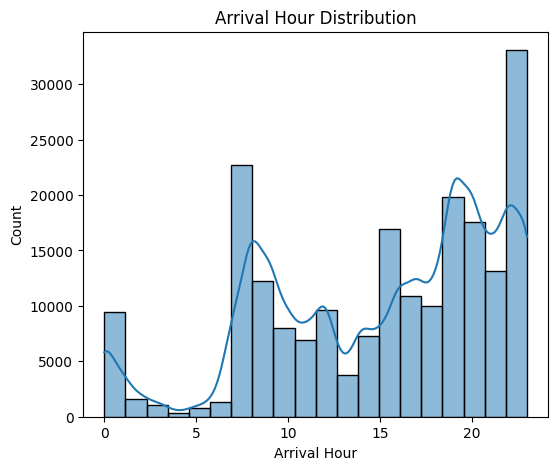

In [9]:
print(df['arr_hour'].describe())
print(df.groupby('airline')['arr_hour'].describe())

plt.figure(figsize=(6,5))
sns.histplot(df['arr_hour'], bins= 20, kde= True, edgecolor= 'black')
plt.xlabel('Arrival Hour')
plt.ylabel('Count')
plt.title('Arrival Hour Distribution')
plt.show()

## Departure hour
**Overall median `12` hours hai (business mein 13 tha).**

**`AirAsia`, `SpiceJet`, `StarAir` sabse late depart karte hain (median 14 hrs), sabse early `Trujet` (8 hrs, chota sample) phir `Vistara`/`Indigo` (12 hrs).**

count    206772.000000
mean         12.844524
std           5.359439
min           0.000000
25%           8.000000
50%          12.000000
75%          18.000000
max          23.000000
Name: dep_hour, dtype: float64
             count       mean       std  min  25%   50%   75%   max
airline                                                            
Air India  47994.0  12.879672  5.386676  2.0  8.0  13.0  18.0  23.0
AirAsia    16098.0  13.511927  5.838278  0.0  9.0  14.0  19.0  23.0
GO FIRST   23177.0  12.581223  5.595306  2.0  8.0  13.0  17.0  23.0
Indigo     43120.0  12.349652  5.099632  0.0  8.0  12.0  16.0  23.0
SpiceJet    9011.0  13.034180  5.891617  4.0  7.0  14.0  19.0  23.0
StarAir       61.0  13.573770  5.361775  7.0  7.0  14.0  20.0  20.0
Trujet        41.0   9.048780  1.759989  8.0  8.0   8.0   9.0  15.0
Vistara    67270.0  13.043913  5.192044  5.0  8.0  12.0  18.0  22.0


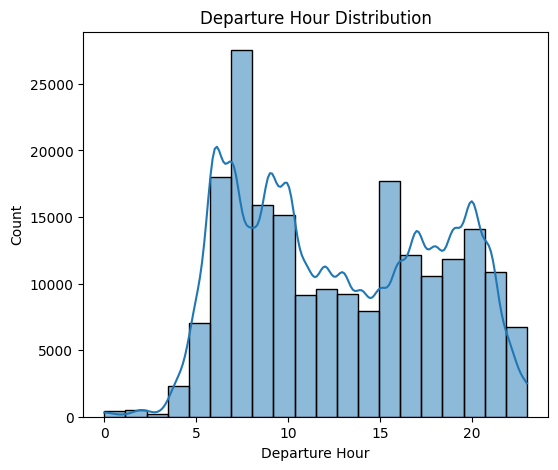

In [10]:
print(df['dep_hour'].describe())
print(df.groupby('airline')['dep_hour'].describe())

plt.figure(figsize=(6,5))
sns.histplot(df['dep_hour'], bins= 20, kde= True, edgecolor= 'black')
plt.xlabel('Departure Hour')
plt.ylabel('Count')
plt.title('Departure Hour Distribution')
plt.show()

## Arrival Period
**`30.87%` flights `Night` (8pm-12am) mein arrive karti hain — sabse zyada.**

**`Late_Night` (12am-6am) mein sirf `6.46%` flights arrive karti hain — sabse kam.**

arr_period
Night         30.870718
Morning       24.752384
Evening       19.713017
Afternoon     18.206527
Late_Night     6.457354
Name: count, dtype: float64


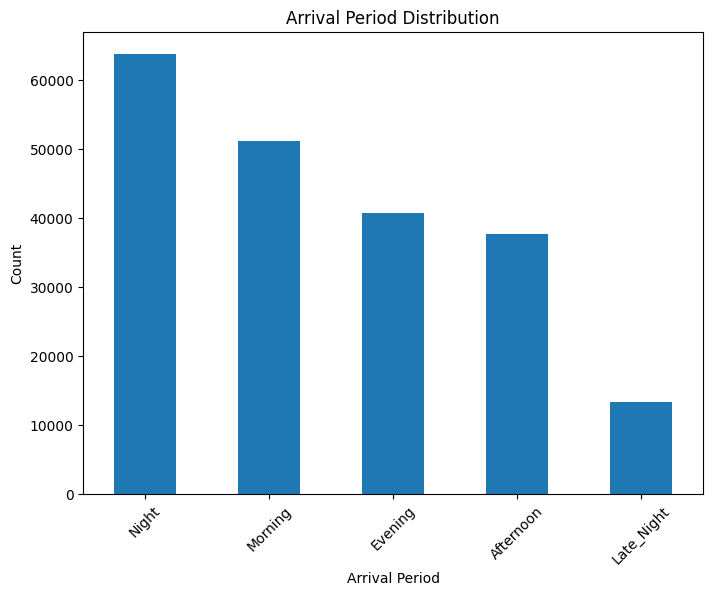

In [11]:
print(df['arr_period'].value_counts()*100/len(df))

plt.figure(figsize=(8,6))
df['arr_period'].value_counts().plot(kind= 'bar')
plt.xlabel('Arrival Period')
plt.ylabel('Count')
plt.title('Arrival Period Distribution')
plt.xticks(rotation=45)
plt.show()

## Departure period
**`41.45%` flights `Morning` mein depart karti hain — bohot morning-heavy hai. `Late_Night` sabse kam (`5.01%`).**

dep_period
Morning       41.450970
Afternoon     21.507264
Evening       16.700520
Night         15.329929
Late_Night     5.011317
Name: count, dtype: float64


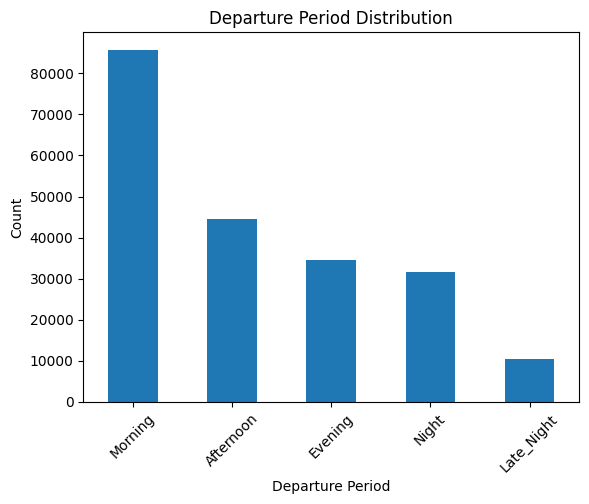

In [12]:
print(df['dep_period'].value_counts()*100/len(df))

df['dep_period'].value_counts().plot(kind='bar')
plt.xlabel('Departure Period')
plt.ylabel('Count')
plt.title('Departure Period Distribution')
plt.xticks(rotation=45)
plt.show()

## Duration_minutes
**Median duration `610 minutes` (~10 hrs 10 mins) hai — business (785 mins) se kam. Skewness `0.78` hai (business mein 0.27 thi).**

**IQR-based outliers `1.28%` hain (upper bound 1725 mins) — duration mein layover time bhi included hai isliye ye outliers valid hain, jaisa business mein tha.**

count    206772.000000
mean        692.738161
std         434.530286
min          50.000000
25%         375.000000
50%         610.000000
75%         915.000000
max        2990.000000
Name: duration_mins, dtype: float64


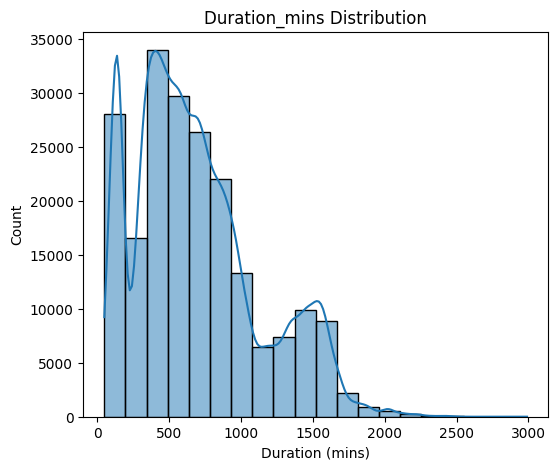

0.7792723435677187


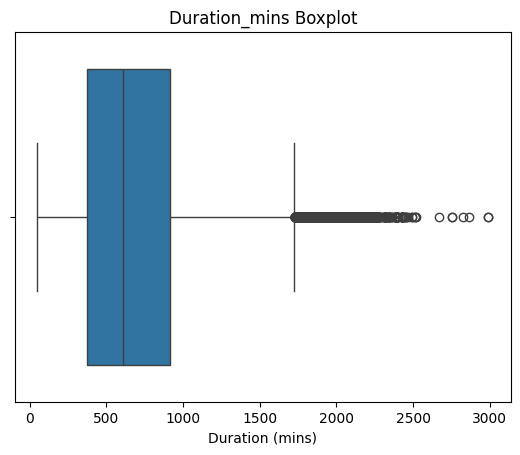

,date,airline,ch_code,flight_number,from,to,via_city,route,stop_count,arr_hour,arr_period,dep_hour,dep_period,duration_mins,price
82,2022-02-11,Air India,AI,801,Delhi,Mumbai,NaN,Delhi-Mumbai,1,22,Night,17,Evening,1760,16245
114,2022-02-11,Air India,AI,429,Delhi,Mumbai,Chennai,Delhi-Mumbai,1,15,Afternoon,9,Morning,1805,24540
357,2022-02-13,Air India,AI,429,Delhi,Mumbai,Chennai,Delhi-Mumbai,1,15,Afternoon,9,Morning,1805,15405
363,2022-02-13,Air India,AI,801,Delhi,Mumbai,NaN,Delhi-Mumbai,1,22,Night,17,Evening,1760,16245
546,2022-02-14,Air India,AI,429,Delhi,Mumbai,Chennai,Delhi-Mumbai,1,15,Afternoon,9,Morning,1805,15720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205635,2022-03-18,Vistara,UK,822,Chennai,Hyderabad,NaN,Chennai-Hyderabad,2,20,Night,9,Morning,2110,6015
205636,2022-03-18,Vistara,UK,828,Chennai,Hyderabad,NaN,Chennai-Hyderabad,2,20,Night,7,Morning,2275,6015
205745,2022-03-19,Air India,AI,429,Chennai,Hyderabad,NaN,Chennai-Hyderabad,2,23,Night,13,Afternoon,2055,9691
205808,2022-03-20,Vistara,UK,826,Chennai,Hyderabad,NaN,Chennai-Hyderabad,2,20,Night,12,Afternoon,1945,6015


In [13]:
print(df['duration_mins'].describe())

plt.figure(figsize=(6,5))
sns.histplot(df['duration_mins'], bins= 20, kde= True, edgecolor= 'black')
plt.xlabel('Duration (mins)')
plt.ylabel('Count')
plt.title('Duration_mins Distribution')
plt.show()

print(df['duration_mins'].skew())

sns.boxplot(df['duration_mins'], orient='h')
plt.xlabel('Duration (mins)')
plt.title('Duration_mins Boxplot')
plt.show()

# Outliers overview
Q3 = df['duration_mins'].quantile(0.75)
Q1 = df['duration_mins'].quantile(0.25)

IQR = Q3-Q1
upper_bound = 1.5*IQR + Q3

df[df['duration_mins'] > upper_bound]

## Bivariate Analysis

## Airline vs Price
**`Vistara` ka median price (₹6,461) sabse zyada hai, `Air India` (₹6,082) second hai.**

**Business jaisa hi — `Vistara` `Air India` se costlier hai, aur gap duration/stop_count se explain nahi hota: `Vistara` ka average duration (806 mins) `Air India` (966 mins) se kam hai phir bhi price zyada hai.**

**`20/30` routes mein `Vistara` `Air India` se costlier hai (business mein 26/30 tha) — economy mein ye premium thoda kam consistent hai route-level pe.**

             count         mean          std     min     25%     50%     75%  \
airline                                                                        
Air India  47994.0  7313.682169  3989.521406  1526.0  4556.0  6082.0  9135.0   
AirAsia    16098.0  4091.072742  2824.055172  1105.0  2361.0  3276.0  4589.0   
GO FIRST   23177.0  5651.930578  2513.669305  1105.0  4205.0  5336.0  6324.0   
Indigo     43120.0  5324.216303  3268.894831  1105.0  3219.0  4453.0  6489.0   
SpiceJet    9011.0  6179.278881  2999.630406  1106.0  4197.0  5654.0  7412.0   
StarAir       61.0  4932.655738  3487.874935  2000.0  2115.0  4337.0  8582.0   
Trujet        41.0  3244.634146   305.184596  3124.0  3166.0  3196.0  3196.0   
Vistara    67270.0  7806.943645  3854.572559  1714.0  5206.0  6461.0  9945.0   

               max  
airline             
Air India  42349.0  
AirAsia    31917.0  
GO FIRST   32803.0  
Indigo     31952.0  
SpiceJet   34158.0  
StarAir    17482.0  
Trujet      4844.0  
Vistara   

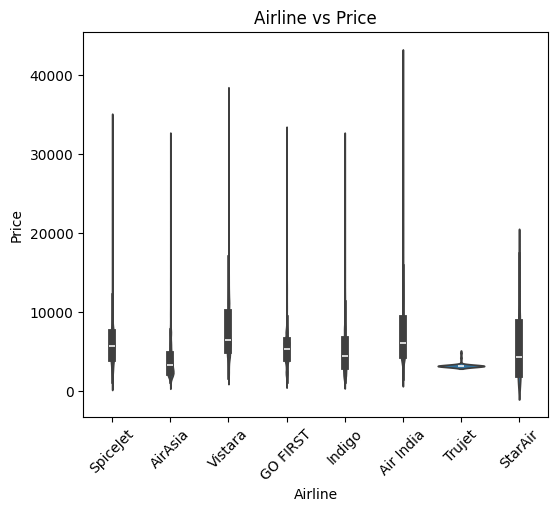

           duration_mins  stop_count
airline                             
Air India     966.005438    0.998750
AirAsia       536.489315    0.988322
GO FIRST      525.259740    0.878500
Indigo        347.709416    0.757004
SpiceJet      754.769726    0.726778
StarAir       145.983607    0.344262
Trujet        232.073171    1.000000
Vistara       806.498588    1.004564


airline    from       to       
Air India  Bangalore  Chennai      8219.478261
                      Delhi        6787.892258
                      Hyderabad    8107.723730
                      Kolkata      8662.251742
                      Mumbai       7342.073755
                                      ...     
Vistara    Mumbai     Bangalore    7820.204354
                      Chennai      7424.020525
                      Delhi        6921.745548
                      Hyderabad    6231.473280
                      Kolkata      8258.270193
Name: price, Length: 183, dtype: float64

In [14]:
print(df.groupby('airline')['price'].describe())

plt.figure(figsize=(6,5))
sns.violinplot(data = df, x= 'airline', y='price')
plt.xlabel('Airline')
plt.ylabel('Price')
plt.title('Airline vs Price')
plt.xticks(rotation=45)
plt.show()

print(df.groupby(['airline'])[['duration_mins','stop_count']].mean())

df.groupby(['airline', 'from', 'to'])['price'].mean()

## Departure_city
**`Kolkata` yahan bhi sabse costly departure city hai — same mechanism jaisa business mein tha: `Kolkata` ka non-stop share sabse kam hai (`10.70%`), jabki `Delhi` ka sabse zyada (`16.86%`) lekin `Delhi` ka overall median price sabse kam hai. Non-stop availability hi asli driver hai, city khud nahi.**

             count         mean          std     min     25%     50%     75%  \
from                                                                           
Bangalore  35665.0  6581.002804  3694.470877  1603.0  4111.0  5733.0  7813.0   
Chennai    26171.0  6606.279699  4193.299727  1105.0  4079.0  5206.0  7877.0   
Delhi      43027.0  6288.585423  3627.729655  1998.0  4000.0  5504.0  7425.0   
Hyderabad  27990.0  6229.956306  3530.054224  1543.0  4230.0  5441.0  7496.0   
Kolkata    32874.0  7458.632354  3712.278951  2436.0  5120.0  6461.0  8169.0   
Mumbai     41045.0  6358.375515  3654.238185  1890.0  4069.0  5667.0  7576.0   

               max  
from                
Bangalore  40354.0  
Chennai    42349.0  
Delhi      35145.0  
Hyderabad  33853.0  
Kolkata    34944.0  
Mumbai     34188.0  


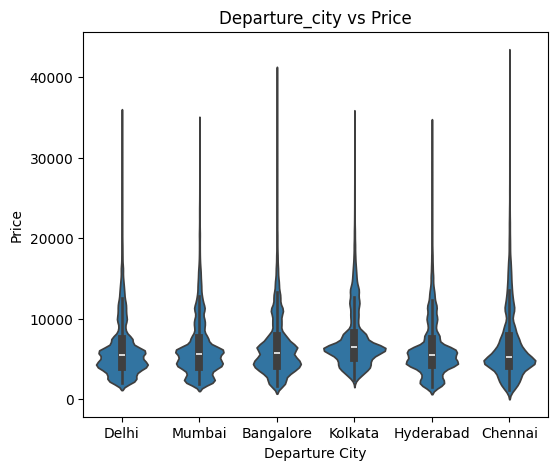

stop_count      0      1     2
from                          
Bangalore   13.53  80.56  5.91
Chennai     11.77  81.93  6.30
Delhi       16.86  77.35  5.79
Hyderabad   11.80  83.35  4.84
Kolkata     10.70  81.64  7.66
Mumbai      14.52  80.40  5.08


from
Delhi        43027
Mumbai       41045
Bangalore    35665
Kolkata      32874
Hyderabad    27990
Chennai      26171
Name: count, dtype: int64

In [15]:
print(df.groupby('from')['price'].describe())

plt.figure(figsize=(6,5))
sns.violinplot(data = df, x= 'from', y='price')
plt.xlabel('Departure City')
plt.ylabel('Price')
plt.title('Departure_city vs Price')
plt.show()

stop_proportion = (
    df.groupby('from')['stop_count']
    .value_counts(normalize=True)
    .unstack()
    .round(4) * 100
)
print(stop_proportion)
df['from'].value_counts()

**Destination city mein bhi same pattern confirm hota hai. `Kolkata` costliest destination hai (lowest non-stop share `9.91%`), jabki `Delhi` ka non-stop share sabse zyada hai destination mein bhi (`17.73%`) — is baar `Chennai` sabse cheap destination hai, lekin non-stop-availability wala mechanism dono directions mein consistent hai.**

             count         mean          std     min     25%     50%     75%  \
to                                                                             
Bangalore  34914.0  6613.978089  3767.629521  1443.0  4230.0  5936.0  7805.0   
Chennai    27210.0  6641.605072  4101.255821  1543.0  4170.0  5348.0  7950.0   
Delhi      40654.0  6251.085650  3589.816283  2051.0  3999.0  5547.0  7353.0   
Hyderabad  29101.0  6304.002680  3544.868280  1105.0  4099.0  5657.0  7584.0   
Kolkata    34777.0  7200.459873  3796.490979  2056.0  4893.0  5960.0  8198.0   
Mumbai     40116.0  6458.797986  3644.349171  1830.0  4190.0  5740.0  7774.0   

               max  
to                  
Bangalore  36911.0  
Chennai    35145.0  
Delhi      34968.0  
Hyderabad  30760.0  
Kolkata    42349.0  
Mumbai     40354.0  


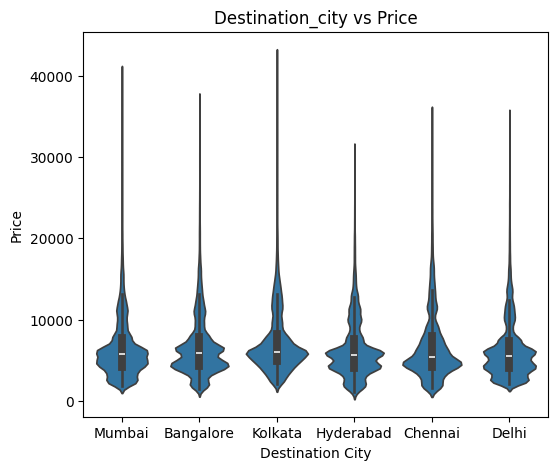

stop_count      0      1     2
to                            
Bangalore   13.82  78.60  7.57
Chennai     11.45  78.57  9.98
Delhi       17.73  80.43  1.84
Hyderabad   11.60  81.47  6.93
Kolkata      9.91  81.74  8.35
Mumbai      14.88  82.18  2.94


to
Delhi        40654
Mumbai       40116
Bangalore    34914
Kolkata      34777
Hyderabad    29101
Chennai      27210
Name: count, dtype: int64

In [16]:
print(df.groupby('to')['price'].describe())

plt.figure(figsize=(6,5))
sns.violinplot(data = df, x= 'to', y='price')
plt.xlabel('Destination City')
plt.ylabel('Price')
plt.title('Destination_city vs Price')
plt.show()

stop_proportion = (
    df.groupby('to')['stop_count']
    .value_counts(normalize=True)
    .unstack()
    .round(4) * 100
)
print(stop_proportion)
df['to'].value_counts()

## Route vs Price
**`Kolkata-Chennai` aur `Kolkata-Bangalore` sabse costly routes hain (median ~₹6,489) — `Kolkata` yahan bhi involved hai jaisa city-level analysis mein tha. Sabse cheap route `Mumbai-Hyderabad` hai (₹4,263).**

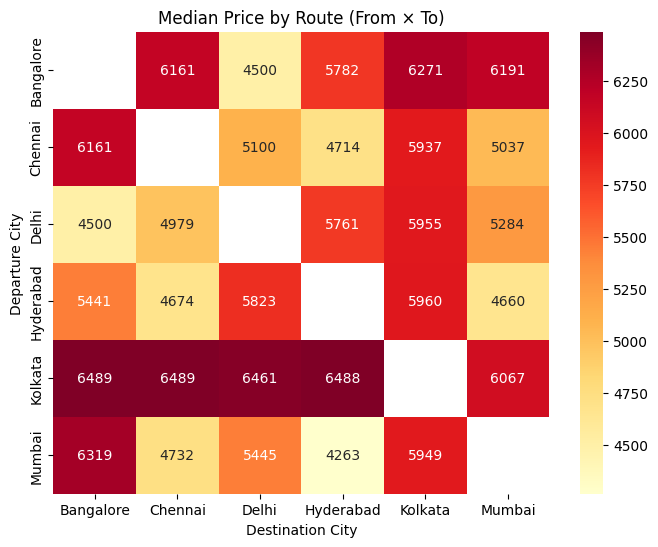

In [17]:
pivot = df.pivot_table(index='from', columns='to', values='price', aggfunc='median')
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.xlabel('Destination City')
plt.ylabel('Departure City')
plt.title('Median Price by Route (From × To)')
plt.show()

## Stop Count
**Price aur stop_count ka relation business se bhi zyada clean hai — `0-stop` median ₹3,499, `1-stop` ₹5,937, `2-stop` ₹8,012 — pura clean upward trend. Business mein 1-stop hi costliest tha, yahan `2-stop` sabse costly hai.**

**Sabse costly ticket `Air India` ki `Chennai-Kolkata` `1-stop` flight hai (₹42,349).**

               count         mean          std     min     25%     50%  \
stop_count                                                               
0            27942.0  4010.662157  2105.877799  1105.0  2350.0  3499.0   
1           166625.0  6812.278884  3658.320303  1105.0  4416.0  5937.0   
2            12205.0  9141.545678  4704.858946  1966.0  6082.0  8012.0   

                75%      max  
stop_count                    
0            4851.5  21058.0  
1            7950.0  42349.0  
2           12157.0  35145.0  


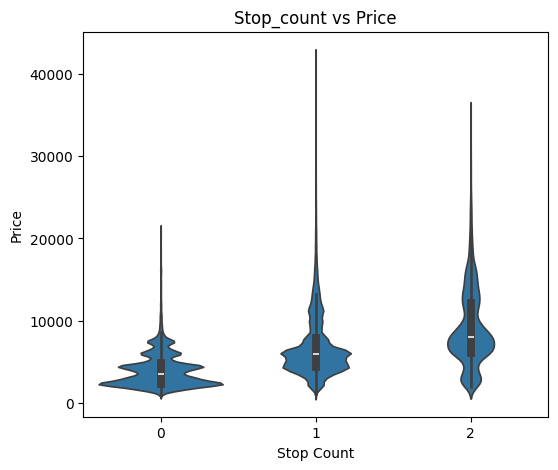

,date,airline,ch_code,flight_number,from,to,via_city,route,stop_count,arr_hour,arr_period,dep_hour,dep_period,duration_mins,price
197915,2022-02-11,Air India,AI,539,Chennai,Kolkata,NaN,Chennai-Kolkata,1,17,Evening,17,Evening,1475,42349


In [18]:
print(df.groupby('stop_count')['price'].describe())

plt.figure(figsize=(6,5))
sns.violinplot(data = df, x= 'stop_count', y='price')
plt.xlabel('Stop Count')
plt.ylabel('Price')
plt.title('Stop_count vs Price')
plt.show()

df[df['price'] == df['price'].max()]

## Arrival_Period vs Price
**`Evening` arrival sabse costly hai (₹6,109), `Late_Night` sabse cheap (₹4,439).**

**Business ke ulat, yahan `stop_count` bhi is pattern ko partially explain karta hai — `Evening` ka average stop_count sabse zyada hai (0.98) aur `Late_Night` ka sabse kam (0.88). Business mein stop_count bilkul flat tha arr_period ke across, yahan nahi hai.**

**`Late_Night` ka sample size bhi chota hai (~6.46% of total flights) isliye is number pe poora bharosa mat karna.**

              count         mean          std     min     25%     50%     75%  \
arr_period                                                                      
Afternoon   37646.0  6672.079637  3842.618901  1105.0  4253.0  5835.0  7877.0   
Evening     40761.0  7145.752803  4019.856540  1105.0  4452.0  6109.0  8753.0   
Late_Night  13352.0  5151.186339  2941.874036  1105.0  3090.0  4439.0  6389.0   
Morning     51181.0  6219.290498  3470.715608  1105.0  4000.0  5485.0  7312.0   
Night       63832.0  6723.918552  3759.964300  1105.0  4359.0  5881.0  7927.0   

                max  
arr_period           
Afternoon   40354.0  
Evening     42349.0  
Late_Night  31707.0  
Morning     35145.0  
Night       37646.0  


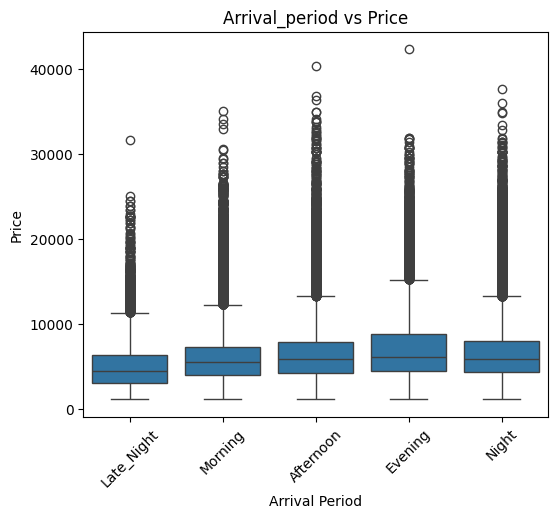

arr_period
Afternoon     0.904691
Evening       0.980913
Late_Night    0.879044
Morning       0.881479
Night         0.942192
Name: stop_count, dtype: float64

In [19]:
print(df.groupby('arr_period')['price'].describe())

order = ['Late_Night','Morning','Afternoon','Evening','Night']

plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='arr_period', y='price', order=order)
plt.xlabel('Arrival Period')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.title('Arrival_period vs Price')
plt.show()

df.groupby('arr_period')['stop_count'].mean()

## Departure_period vs Price
**`Morning` departure sabse costly hai (₹5,955), `Night` sabse cheap (₹5,441) — arrival period se ulta pattern (waha Evening costly tha).**

**Yahan bhi `stop_count` thoda vary karta hai periods ke across (Morning 0.96 vs Night 0.84), same partial-explanation wala pattern jo arrival period mein tha.**

              count         mean          std     min      25%     50%  \
dep_period                                                               
Afternoon   44471.0  6374.901734  3692.903252  1105.0  4020.00  5535.0   
Evening     34532.0  6507.753359  3629.223164  1105.0  4149.00  5761.0   
Late_Night  10362.0  5839.755453  3495.520147  1105.0  3756.00  5067.0   
Morning     85709.0  6938.652884  3893.583822  1105.0  4416.00  5955.0   
Night       31698.0  6161.080068  3489.862310  1105.0  3998.25  5441.0   

               75%      max  
dep_period                   
Afternoon   7490.0  40354.0  
Evening     7636.0  42349.0  
Late_Night  6548.0  33613.0  
Morning     8112.0  37646.0  
Night       7212.0  33853.0  


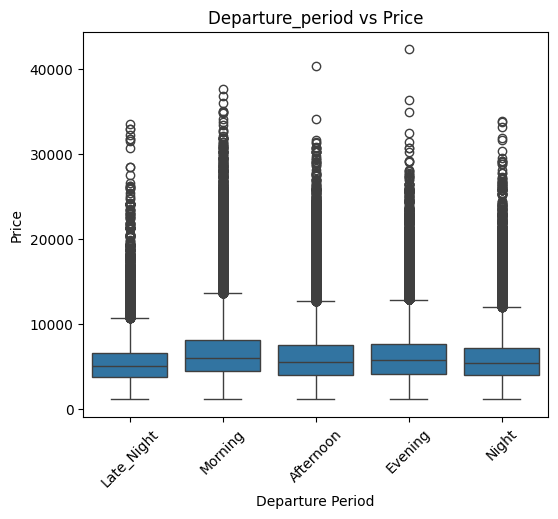

dep_period
Afternoon     0.957118
Evening       0.882660
Late_Night    0.874831
Morning       0.960868
Night         0.838255
Name: stop_count, dtype: float64

In [20]:
print(df.groupby('dep_period')['price'].describe())

order = ['Late_Night','Morning','Afternoon','Evening','Night']

plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='dep_period', y='price', order=order)
plt.xlabel('Departure Period')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.title('Departure_period vs Price')
plt.show()

df.groupby('dep_period')['stop_count'].mean()

## `Duration_mins` vs `Price`
**Pearson corr `0.29`, Spearman `0.36` — dono business se zyada hain (business mein 0.24/0.16 tha), matlab economy mein duration price ke saath thoda strongly related hai.**

**Bucket-wise median dekhne pe pattern bhi different hai business se — business mein 800 mins ke baad median plateau ho ke thoda decline hua tha, lekin economy mein median steadily badhta rehta hai 200 se 1600 mins tak — genuine continuous relationship hai, sirf ek threshold jump nahi.**

**1800 mins ke baad sample size chota ho jata hai isliye us tail pe zyada bharosa mat karna, jaisa business mein bhi tha.**

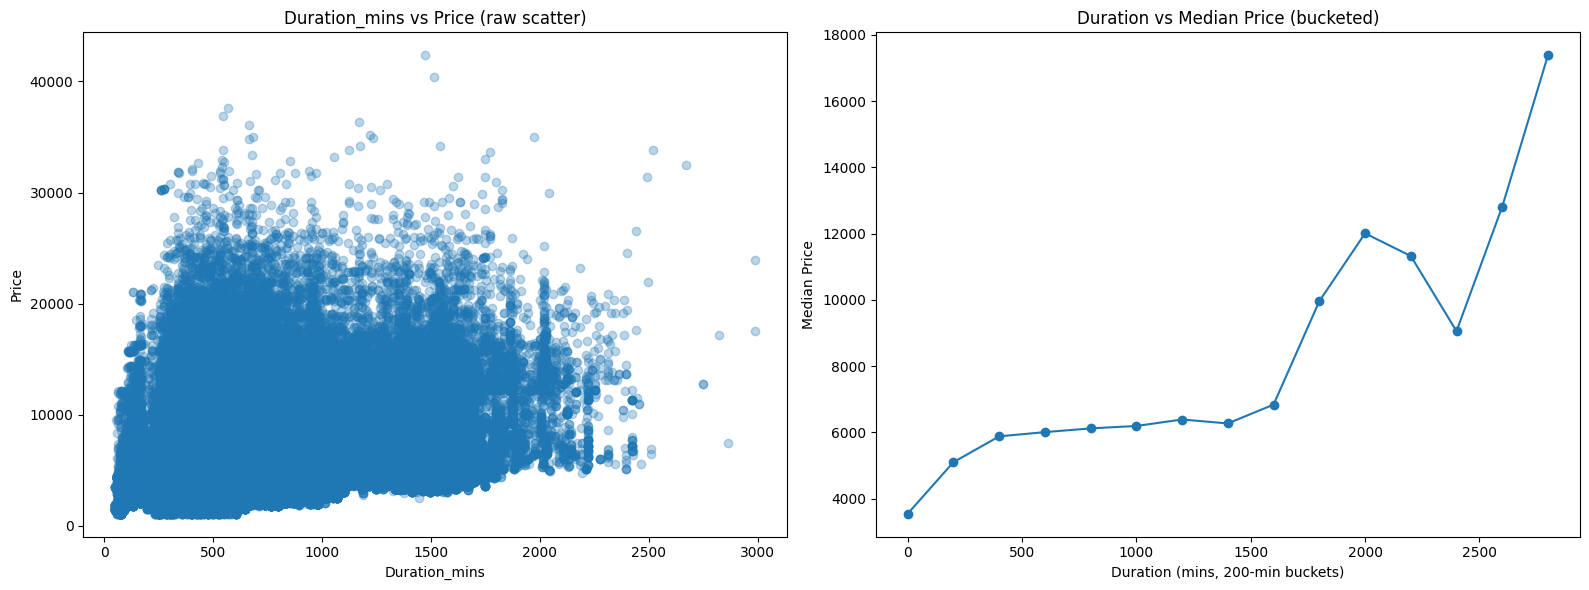

duration_bucket
0       28061
200     28966
400     43484
600     37054
800     26531
1000    11087
1200    10510
1400    14168
1600     4872
1800     1141
2000      661
2200      190
2400       40
2600        3
2800        4
Name: price, dtype: int64


In [21]:
df['duration_bucket'] = (df['duration_mins'] // 200) * 200
bucket_median = df.groupby('duration_bucket')['price'].median()
bucket_count = df.groupby('duration_bucket')['price'].count()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].scatter(df['duration_mins'], df['price'], alpha=0.3)
ax[0].set_xlabel('Duration_mins')
ax[0].set_ylabel('Price')
ax[0].set_title('Duration_mins vs Price (raw scatter)')

bucket_median.plot(ax=ax[1], marker='o')
ax[1].set_xlabel('Duration (mins, 200-min buckets)')
ax[1].set_ylabel('Median Price')
ax[1].set_title('Duration vs Median Price (bucketed)')

plt.tight_layout()
plt.show()

print(bucket_count)

## Days_left vs Price
**Ye section economy dataset mein applicable nahi hai — `days_left` column economy_cleaned.csv mein exist hi nahi karta.**

**Wajah: business.csv ke liye Clean_Dataset.csv se `days_left` ek verified 1:1 row-order match ke through attach ho paya tha. Economy.csv ke liye same match nahi mila — same flight/price combination kai alag-alag dates pe repeat hota hai, isliye ek reliable join possible nahi tha (check kiya tha: ~85% economy rows ambiguous nikle the). Isliye galat/guessed values dene se better hai ye feature economy mein include hi na karna.**

In [22]:
# days_left column economy dataset mein available nahi hai (upar wajah likhi hai)
# isliye ye cell skip kar rahe hain
pass

## Airline vs Stop_count
**Economy mein airlines ke beech stop_count distribution mein business se zyada variation hai. `StarAir` (65.57% non-stop) sabse alag hai (lekin sample chota hai — 61 flights, trust mat karo).**

**Bade airlines mein: `Indigo`/`SpiceJet` ka non-stop share (~26-27%) `Air India`/`Vistara` (~7-8%) se kaafi zyada hai — business mein dono airlines ka non-stop share kaafi similar tha (~8-9%), economy mein carrier ke hisaab se zyada spread hai.**

In [23]:
(df.groupby('airline')['stop_count'].value_counts(normalize=True)*100).unstack()

stop_count,0,1,2
airline,,,
Air India,6.917531,86.289953,6.792516
AirAsia,15.119891,70.928066,13.952044
GO FIRST,13.906028,84.337921,1.756051
Indigo,26.011132,72.277365,1.711503
SpiceJet,27.322162,72.677838,NaN
StarAir,65.573770,34.426230,NaN
Trujet,NaN,100.000000,NaN
Vistara,7.799911,83.943809,8.256281


## Airline vs Route
**`20/30` routes mein `Vistara` `Air India` se costlier hai (business mein 26/30 tha) — economy mein airline premium route-level pe thoda kam consistent hai.**

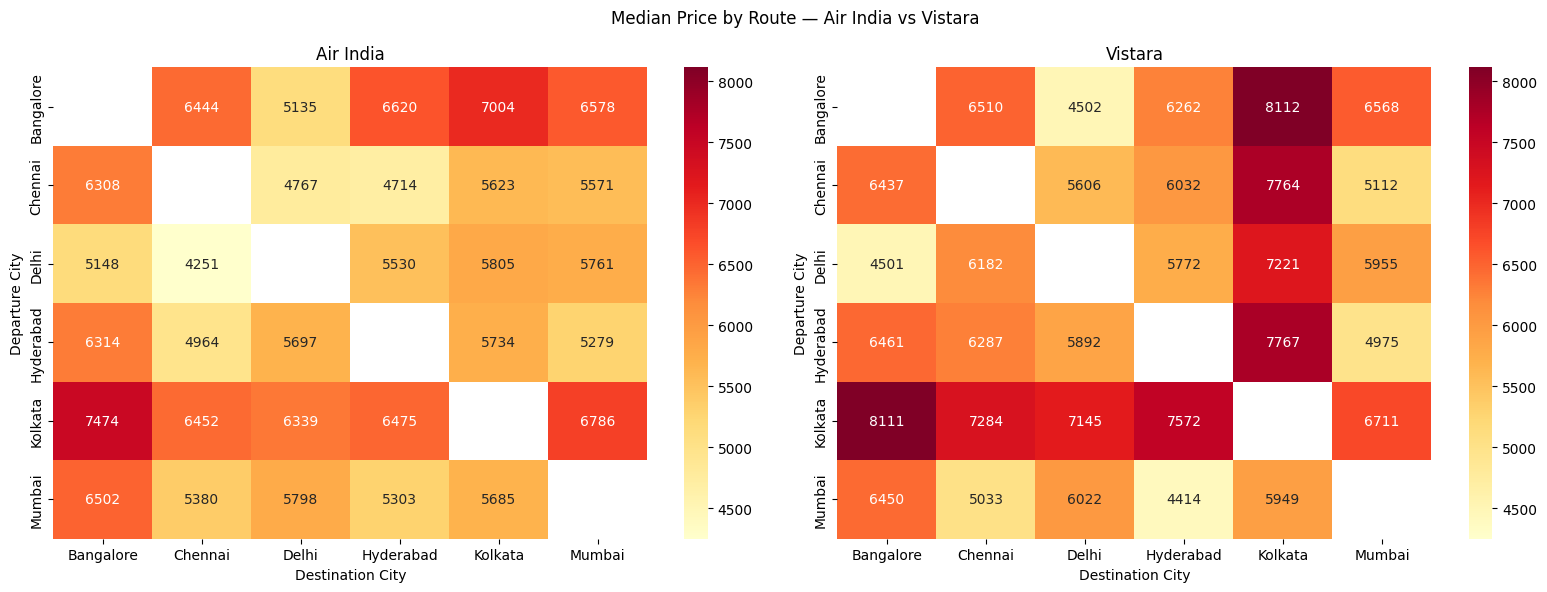

In [24]:
ai = df[df['airline'] == 'Air India']
vi = df[df['airline'] == 'Vistara']

vmin = df[df['airline'].isin(['Air India','Vistara'])].groupby(['airline','from','to'])['price'].median().min()
vmax = df[df['airline'].isin(['Air India','Vistara'])].groupby(['airline','from','to'])['price'].median().max()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_ai = ai.pivot_table(index='from', columns='to', values='price', aggfunc='median')
sns.heatmap(pivot_ai, annot=True, fmt='.0f', cmap='YlOrRd', vmin=vmin, vmax=vmax, ax=axes[0])
axes[0].set_xlabel('Destination City')
axes[0].set_ylabel('Departure City')
axes[0].set_title('Air India')

pivot_vi = vi.pivot_table(index='from', columns='to', values='price', aggfunc='median')
sns.heatmap(pivot_vi, annot=True, fmt='.0f', cmap='YlOrRd', vmin=vmin, vmax=vmax, ax=axes[1])
axes[1].set_xlabel('Destination City')
axes[1].set_ylabel('Departure City')
axes[1].set_title('Vistara')

plt.suptitle('Median Price by Route — Air India vs Vistara')
plt.tight_layout()
plt.show()

In [25]:
df['day_of_week'] = df['date'].dt.day_name()
df['is_weekend'] = np.where(df['day_of_week'].isin(['Sunday','Saturday']), 1, 0)

In [26]:
order = ['date', 'day_of_week', 'is_weekend', 'airline', 'ch_code', 'flight_number', 'from', 'to', 'via_city',
       'route', 'stop_count', 'arr_hour', 'arr_period', 'dep_hour',
       'dep_period', 'duration_mins', 'price', 'duration_bucket'
        ]

df = df[order]
df.sample(3)

,date,day_of_week,is_weekend,airline,ch_code,flight_number,from,to,via_city,route,stop_count,arr_hour,arr_period,dep_hour,dep_period,duration_mins,price,duration_bucket
68560,2022-03-22,Tuesday,0,Air India,AI,867,Mumbai,Kolkata,NaN,Mumbai-Kolkata,1,9,Morning,21,Night,690,4977,600
164283,2022-03-22,Tuesday,0,Air India,AI,840,Hyderabad,Mumbai,NaN,Hyderabad-Mumbai,1,11,Morning,20,Night,865,4363,800
150486,2022-03-09,Wednesday,0,Vistara,UK,720,Kolkata,Chennai,NaN,Kolkata-Chennai,1,16,Afternoon,7,Morning,550,6009,400


## Day_of_Week vs Price
**Business jaisa hi mostly flat hai, lekin economy mein Fri/Sat/Sun ki taraf chota sa uptick dikhta hai (₹5,913–5,949) Mon-Wed (₹5,550–5,640) ke comparison mein — business mein ye bilkul flat tha, yahan chota sa effect visible hai.**

               count         mean          std     min     25%     50%  \
day_of_week                                                              
Monday       30227.0  6314.098819  3434.380855  1105.0  4095.0  5632.0   
Tuesday      30354.0  6208.377776  3333.381846  1105.0  4054.0  5550.0   
Wednesday    30276.0  6281.351764  3306.018985  1105.0  4111.0  5640.0   
Thursday     30342.0  6333.411344  3344.030527  1105.0  4165.0  5708.0   
Friday       27794.0  6970.399942  4034.511451  1105.0  4348.0  5949.0   
Saturday     28607.0  7008.861118  4361.443266  1105.0  4274.0  5915.0   
Sunday       29172.0  6953.542198  4191.980513  1105.0  4324.0  5913.5   

                75%      max  
day_of_week                   
Monday       7455.0  33401.0  
Tuesday      7424.0  30284.0  
Wednesday    7487.0  33813.0  
Thursday     7487.0  31773.0  
Friday       8381.0  42349.0  
Saturday     8056.0  35145.0  
Sunday       8111.0  40354.0  


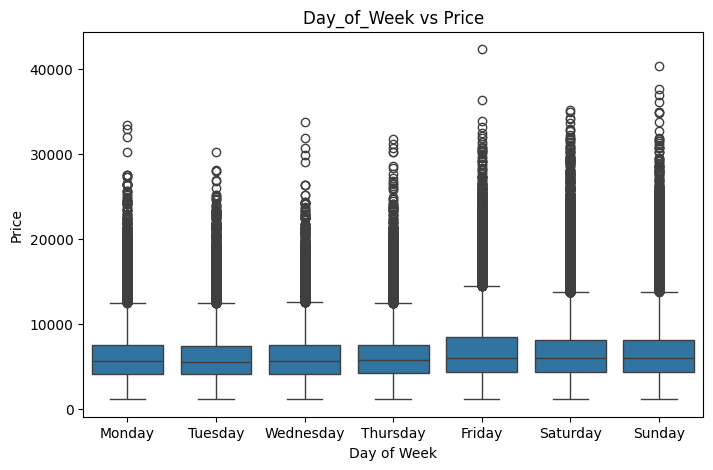

In [27]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
print(df.groupby('day_of_week')['price'].describe().reindex(day_order))

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='day_of_week', y='price', order=day_order)
plt.xlabel('Day of Week')
plt.ylabel('Price')
plt.title('Day_of_Week vs Price')
plt.show()

               count         mean          std     min     25%     50%  \
is_weekend                                                               
0           148993.0  6412.269254  3502.041288  1105.0  4149.0  5723.0   
1            57779.0  6980.931186  4276.775090  1105.0  4294.0  5915.0   

               75%      max  
is_weekend                   
0           7572.0  42349.0  
1           8102.0  40354.0  


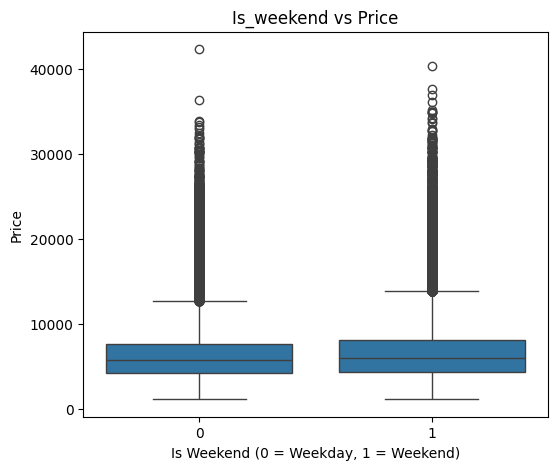

In [28]:
print(df.groupby('is_weekend')['price'].describe())

plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='is_weekend', y='price')
plt.xlabel('Is Weekend (0 = Weekday, 1 = Weekend)')
plt.ylabel('Price')
plt.title('Is_weekend vs Price')
plt.show()

In [29]:
df.columns

Index(['date', 'day_of_week', 'is_weekend', 'airline', 'ch_code',
       'flight_number', 'from', 'to', 'via_city', 'route', 'stop_count',
       'arr_hour', 'arr_period', 'dep_hour', 'dep_period', 'duration_mins',
       'price', 'duration_bucket'],
      dtype='str')

## Overall Summary — Economy Class EDA

- **Business jaisa hi `stop_count` sabse bada price driver hai**, aur economy mein trend aur bhi clean hai — 0-stop, 1-stop, 2-stop teeno stages mein consistent upward jump
- **Kolkata/Delhi ka wahi mixing-artifact pattern economy mein bhi confirm hota hai** — non-stop availability hi asli driver hai, city khud nahi
- **`duration_mins` ka economy mein zyada strong aur continuous relationship hai** (business ke threshold-jump-then-flat pattern ke ulat) — Pearson/Spearman dono business se zyada
- **`days_left` economy mein available nahi hai** — Clean_Dataset.csv se reliable join nahi ho paya (~85% rows ambiguous), isliye ye feature is dataset mein missing hai
- **`Vistara` yahan bhi `Air India` se costlier hai**, lekin route-level premium business (26/30) ke comparison mein thoda kam consistent hai (20/30)
- **`day_of_week`/`is_weekend` ka chota sa effect hai** (business mein bilkul flat tha) — Fri/Sat/Sun ki taraf halka sa uptick, lekin practically negligible